# Python Workbook: Quant Portfolio Construction for Complete Beginners

## What this workbook is

This English workbook starts from zero: Python arrays, returns, volatility,
covariance, diversification, and four portfolio rules: equal weight, inverse
volatility, HRP, and HERC.

All data is synthetic. It teaches mechanics safely; it is not market data, a
forecast, investment advice, or a trade instruction.

**Audience:** learners who know basic arithmetic but are new to Python and
quantitative investing.

**Learning goals**

1. Explain why portfolio work uses returns rather than raw prices.
2. Build and inspect labelled return data.
3. Read historical volatility, covariance, and correlation.
4. Estimate covariance with qamr.
5. Compare equal weight, inverse volatility, HRP, and HERC.
6. Inspect portfolio risk contributions and limitations.

> Content drafting note: Gemini 3.5 Flash helped brainstorm beginner learning
> prompts. All code and examples were checked locally.


## Roadmap

1. Set up a reproducible Python workspace.
2. Create synthetic return data.
3. Measure historical return and volatility.
4. Understand covariance and correlation.
5. Estimate covariance with qamr.
6. Construct portfolios and inspect risk contributions.
7. Complete exercises and review limitations.

Install the local project environment before running this notebook:

    pip install -e '.[pandas]'


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from qamr.allocation import (
    equal_weights,
    herc_weights,
    hrp_weights,
    inverse_volatility_weights,
    portfolio_volatility,
    risk_contributions,
)
from qamr.contracts import DatasetMetadata, ReturnConvention
from qamr.contracts.pandas_adapter import PandasAdapter, PandasResearchInput
from qamr.risk import (
    EWMACovariance,
    SampleCovariance,
    ShrinkageCovariance,
    SpectralDenoisedCovariance,
)

SEED = 7
ANNUALIZATION_FACTOR = 252.0  # Explicit caller assumption, never inferred.
rng = np.random.default_rng(SEED)

# Restrained QuantSeras-inspired chart style: neutral dark surface + labelled accents.
plt.rcParams.update({
    "figure.facecolor": "#121212",
    "axes.facecolor": "#1E1E1E",
    "axes.edgecolor": "#BDBDBD",
    "axes.labelcolor": "#F5F5F5",
    "text.color": "#F5F5F5",
    "xtick.color": "#E0E0E0",
    "ytick.color": "#E0E0E0",
    "grid.color": "#555555",
    "grid.alpha": 0.35,
})


## 1. What is a portfolio?

A portfolio is a collection of assets and their weights. A weight is the share
of the portfolio allocated to an asset. For a fully invested long-only
portfolio, weights add to 100%.

Quantitative work usually uses returns instead of prices. A return is a
percentage change, so an asset priced at 10 and one priced at 1,000 can be
compared fairly when each changes by 1%.


In [2]:
portfolio_weights = pd.Series(
    [0.50, 0.30, 0.20],
    index=["Asset A", "Asset B", "Asset C"],
    name="weight",
)
print("Weights sum to:", portfolio_weights.sum())
portfolio_weights


Weights sum to: 1.0


Asset A    0.5
Asset B    0.3
Asset C    0.2
Name: weight, dtype: float64

### Exercise 1: simple return

You buy an asset for 100 and it ends at 105. Calculate the simple return:

    (ending value - starting value) / starting value


In [3]:
starting_value = 100.0
ending_value = 105.0
simple_return = (ending_value - starting_value) / starting_value
print(f"Simple return: {simple_return:.1%}")


Simple return: 5.0%


## 2. Create synthetic return data

Rows represent dates and columns represent assets. A number of 0.01 means a
+1% simple return for that period, while -0.01 means -1%.

We simulate data instead of downloading prices. The fixed seed means every
reader sees the same example.


In [4]:
labels = ("Global Equity", "Government Bonds", "Gold", "REITs")
dates = pd.date_range("2025-01-02", periods=180, freq="B", tz="UTC")

daily_volatility = np.array([0.012, 0.005, 0.010, 0.014])
correlation_assumption = np.array([
    [1.00, -0.20, 0.10, 0.55],
    [-0.20, 1.00, 0.05, -0.10],
    [0.10, 0.05, 1.00, 0.15],
    [0.55, -0.10, 0.15, 1.00],
])
daily_covariance = np.outer(daily_volatility, daily_volatility) * correlation_assumption
daily_mean = np.array([0.00035, 0.00010, 0.00015, 0.00030])

returns_df = pd.DataFrame(
    rng.multivariate_normal(daily_mean, daily_covariance, size=len(dates)),
    index=dates,
    columns=labels,
)
returns_df.head()


,Global Equity,Government Bonds,Gold,REITs
2025-01-02 00:00:00+00:00,0.003236,0.003972,-0.002581,-0.001180
2025-01-03 00:00:00+00:00,0.001724,-0.006018,0.010977,0.006436
2025-01-06 00:00:00+00:00,0.000523,-0.001217,0.006707,0.009183
2025-01-07 00:00:00+00:00,-0.002692,-0.002560,0.009080,-0.001336
2025-01-08 00:00:00+00:00,0.025947,0.003990,0.009796,0.007495


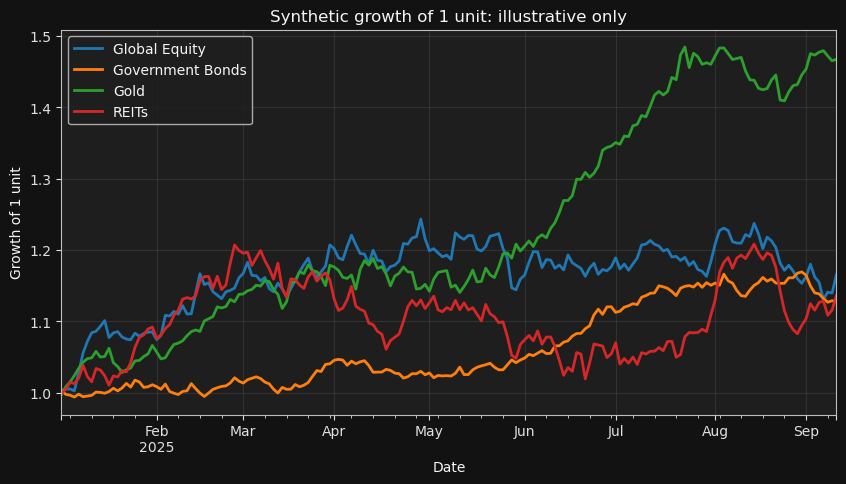

In [5]:
growth_of_one = (1.0 + returns_df).cumprod()
ax = growth_of_one.plot(figsize=(10, 5), linewidth=2)
ax.set_title("Synthetic growth of 1 unit: illustrative only")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1 unit")
ax.grid(True)
plt.show()


## 3. Historical return and volatility

The mean return is the average historical period return. Volatility is the
standard deviation of historical returns. Higher volatility means returns moved
around more in this sample.

Neither number predicts the future. They depend on the selected dates,
frequency, and assumptions.


In [6]:
summary = pd.DataFrame({
    "mean daily return": returns_df.mean(),
    "daily volatility": returns_df.std(ddof=1),
})
summary["annualized volatility (252-day assumption)"] = (
    summary["daily volatility"] * np.sqrt(ANNUALIZATION_FACTOR)
)
summary.style.format("{:.2%}")


,mean daily return,daily volatility,annualized volatility (252-day assumption)
Global Equity,0.09%,1.10%,17.41%
Government Bonds,0.07%,0.50%,7.86%
Gold,0.22%,0.88%,13.89%
REITs,0.08%,1.27%,20.15%


### Exercise 2: which asset is more volatile?

Asset A has returns near +1%, -1%, +1%. Asset B has returns near +10%, -12%,
+8%. Run the next cell and explain why the answer is Asset B.


In [7]:
exercise_a = np.array([0.01, -0.01, 0.01])
exercise_b = np.array([0.10, -0.12, 0.08])
print("Asset A volatility:", exercise_a.std(ddof=1))
print("Asset B volatility:", exercise_b.std(ddof=1))
print("Asset B moves farther from its average return.")


Asset A volatility: 0.011547005383792516
Asset B volatility: 0.1216552506059644
Asset B moves farther from its average return.


## 4. Covariance, correlation, and diversification

Covariance asks whether two return series moved together in this sample.
Correlation standardizes that idea to a range near -1 to +1. A value near +1
means two series tended to move together; a value near -1 means they tended to
move in opposite directions.

Diversification is not a promise of safety. It is the idea that imperfect
relationships can reduce the historical variability of a combined portfolio.


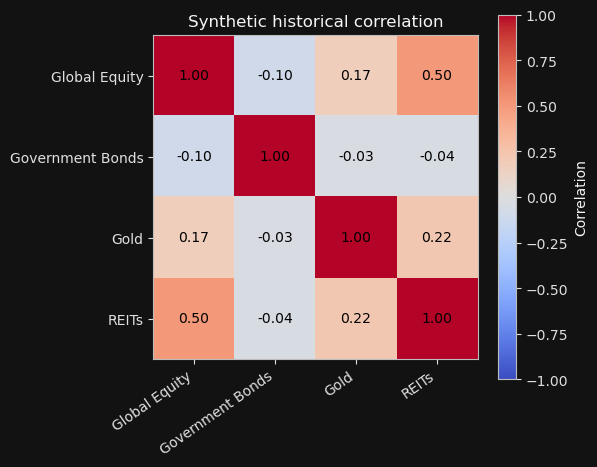

,Global Equity,Government Bonds,Gold,REITs
Global Equity,1.00,-0.10,0.17,0.50
Government Bonds,-0.10,1.00,-0.03,-0.04
Gold,0.17,-0.03,1.00,0.22
REITs,0.50,-0.04,0.22,1.00


In [8]:
pandas_covariance = returns_df.cov()
pandas_correlation = returns_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(pandas_correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Synthetic historical correlation")
for row in range(len(labels)):
    for column in range(len(labels)):
        ax.text(column, row, f"{pandas_correlation.iloc[row, column]:.2f}",
                ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

pandas_correlation.round(2)


## 5. Move from pandas to qamr

qamr keeps numeric values with explicit instrument labels and metadata. Pandas
is the input boundary; qamr estimators then operate on validated labelled
returns.


In [9]:
metadata = DatasetMetadata(
    frequency="business-day",
    timezone="UTC",
    return_convention=ReturnConvention.SIMPLE,
)
dataset = PandasAdapter(metadata=metadata).adapt(
    PandasResearchInput(returns=returns_df)
)
assert dataset.returns is not None
print("Observation count:", dataset.returns.shape[0])
print("Instrument labels:", dataset.returns.column_labels)


Observation count: 180
Instrument labels: ('Global Equity', 'Government Bonds', 'Gold', 'REITs')


## 6. Estimate covariance

No estimator is universally best. Each is a modelling assumption.

- Sample covariance is a transparent historical baseline.
- EWMA gives recent observations more influence.
- Shrinkage moves a noisy estimate toward a simpler structure.
- Spectral denoising separates selected signal directions from noise.

For this beginner workbook we compare annualized volatility outputs. In real
work, document the sample window, parameters, data policy, and limitations.


In [10]:
sample_estimate = SampleCovariance(
    annualization_factor=ANNUALIZATION_FACTOR
).estimate(dataset.returns)

ewma_estimate = EWMACovariance(
    decay=0.97,
    annualization_factor=ANNUALIZATION_FACTOR,
).estimate(dataset.returns)

shrinkage_estimate = ShrinkageCovariance(
    shrinkage=0.25,
    base_estimator=SampleCovariance(annualization_factor=ANNUALIZATION_FACTOR),
).estimate(dataset.returns)

spectral_estimate = SpectralDenoisedCovariance(
    signal_rank=1,
    base_estimator=SampleCovariance(annualization_factor=ANNUALIZATION_FACTOR),
).estimate(dataset.returns)


In [11]:
volatility_by_method = pd.DataFrame({
    "Sample": sample_estimate.volatility.values,
    "EWMA": ewma_estimate.volatility.values,
    "Shrinkage": shrinkage_estimate.volatility.values,
    "Spectral": spectral_estimate.volatility.values,
}, index=labels)
volatility_by_method.style.format("{:.2%}")


,Sample,EWMA,Shrinkage,Spectral
Global Equity,17.41%,17.67%,17.41%,17.41%
Government Bonds,7.86%,8.52%,7.86%,7.86%
Gold,13.89%,13.18%,13.89%,13.89%
REITs,20.15%,21.23%,20.15%,20.15%


### Exercise 3: recent observations

Why might an analyst prefer EWMA after a major market change?

Suggested answer: EWMA can give recent observations more influence, but its
decay setting is still an explicit modelling assumption.


## 7. Construct four portfolios

We use the same sample covariance estimate for each rule.

- Equal weight gives every asset the same capital weight.
- Inverse volatility gives relatively more capital to lower-volatility assets.
- HRP groups related assets in a hierarchy and splits by cluster variance.
- HERC uses the same hierarchy and splits by cluster risk.

These are portfolio-construction rules, not forecasts or a replacement for
objectives, costs, taxes, liquidity, or suitability analysis.


In [12]:
allocations = {
    "Equal Weight": equal_weights(sample_estimate),
    "Inverse Volatility": inverse_volatility_weights(sample_estimate),
    "HRP": hrp_weights(sample_estimate, linkage_method="average"),
    "HERC": herc_weights(sample_estimate, linkage_method="average"),
}

weight_table = pd.DataFrame(
    {name: allocation.values for name, allocation in allocations.items()},
    index=labels,
)
weight_table.style.format("{:.2%}")


,Equal Weight,Inverse Volatility,HRP,HERC
Global Equity,25.00%,18.76%,7.46%,9.91%
Government Bonds,25.00%,41.53%,69.40%,60.09%
Gold,25.00%,23.51%,17.57%,21.44%
REITs,25.00%,16.21%,5.57%,8.56%


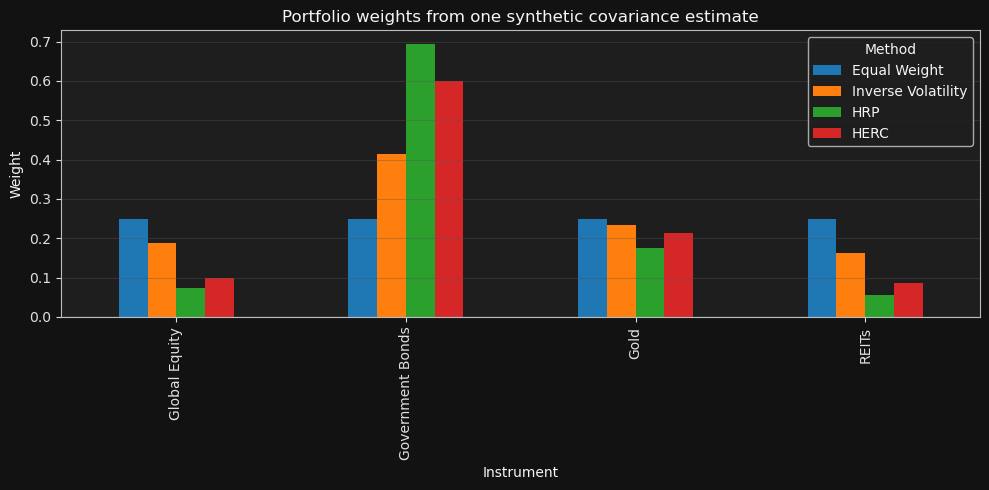

In [13]:
ax = weight_table.plot.bar(figsize=(10, 5))
ax.set_title("Portfolio weights from one synthetic covariance estimate")
ax.set_xlabel("Instrument")
ax.set_ylabel("Weight")
ax.axhline(0.0, color="#BDBDBD", linewidth=0.8)
ax.legend(title="Method")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


## 8. Risk contributions

A capital weight is not a risk contribution. Risk contribution asks how much an
asset contributes to portfolio volatility under the selected covariance
estimate. A small weight can still contribute meaningful risk when its
volatility or relationships are high.


In [14]:
rows = []
for method, allocation in allocations.items():
    contributions = risk_contributions(sample_estimate, allocation)
    for label, weight, contribution in zip(
        labels, allocation.values, contributions.values, strict=True
    ):
        rows.append({
            "method": method,
            "instrument": label,
            "weight": weight,
            "risk contribution": contribution,
        })

risk_table = pd.DataFrame(rows)
portfolio_volatilities = pd.Series(
    {
        method: portfolio_volatility(sample_estimate, allocation)
        for method, allocation in allocations.items()
    },
    name="historical annualized volatility",
)

display(portfolio_volatilities.to_frame().style.format("{:.2%}"))
display(
    risk_table.pivot(
        index="instrument", columns="method", values="risk contribution"
    ).style.format("{:.2%}")
)


,historical annualized volatility
Equal Weight,9.60%
Inverse Volatility,7.62%
HRP,6.30%
HERC,6.40%


method,Equal Weight,HERC,HRP,Inverse Volatility
instrument,,,,
Global Equity,3.30%,0.70%,0.35%,2.20%
Gold,1.90%,1.63%,1.06%,1.90%
Government Bonds,0.25%,3.24%,4.51%,1.16%
REITs,4.16%,0.83%,0.37%,2.36%


### Exercise 4: compare the rules

1. Which rule gives the largest weight to Government Bonds in this synthetic sample?
2. Does the largest capital weight always have the largest risk contribution?
3. Change EWMA decay from 0.97 to 0.90 and rerun the estimator section. Describe
   the historical change without calling it a forecast.


In [15]:
largest_bond_weight = weight_table.loc["Government Bonds"].idxmax()
largest_risk_by_method = (
    risk_table.loc[risk_table.groupby("method")["risk contribution"].idxmax(),
                   ["method", "instrument", "risk contribution"]]
    .set_index("method")
)

print("Largest Government Bonds weight:", largest_bond_weight)
print("\nLargest risk contributor by method:")
largest_risk_by_method.style.format({"risk contribution": "{:.2%}"})


Largest Government Bonds weight: HRP

Largest risk contributor by method:


,instrument,risk contribution
method,,
Equal Weight,REITs,4.16%
HERC,Government Bonds,3.24%
HRP,Government Bonds,4.51%
Inverse Volatility,REITs,2.36%


## Common pitfalls and next steps

1. Historical covariance is not a forecast.
2. Do not mix prices and returns.
3. Keep annualisation, dates, missing-data policy, and estimator settings explicit.
4. Never align assets by position when labels differ.
5. These constructors can reject infeasible constraints; they do not solve every
   possible optimization problem.

Next, replace synthetic returns with a validated user-provided return file and
compare methods under multiple explicit assumptions. Treat backtests, transaction
costs, signals, and market data as separate workflows with their own validation.
